
Dataset:
   Gender  SeniorCitizen  Tenure  MonthlyCharges        Contract  \
0    Male              0       1           29.85  Month-to-month   
1  Female              1      34           56.95        One year   
2  Female              0       2           53.85  Month-to-month   
3    Male              0      45           42.30        Two year   
4    Male              1       5           70.70  Month-to-month   
5  Female              0      22           89.10        One year   
6    Male              1      10           29.75  Month-to-month   
7  Female              0      18           80.65        Two year   
8    Male              0      50           99.65        Two year   
9  Female              1       7           75.25  Month-to-month   

      PaymentMethod Churn  
0  Electronic check   Yes  
1      Mailed check    No  
2     Bank transfer   Yes  
3       Credit card    No  
4  Electronic check   Yes  
5      Mailed check    No  
6     Bank transfer   Yes  
7       Credit ca

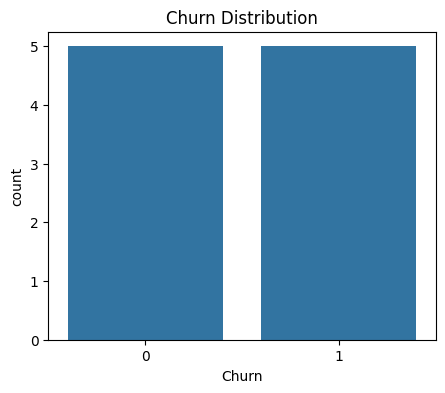

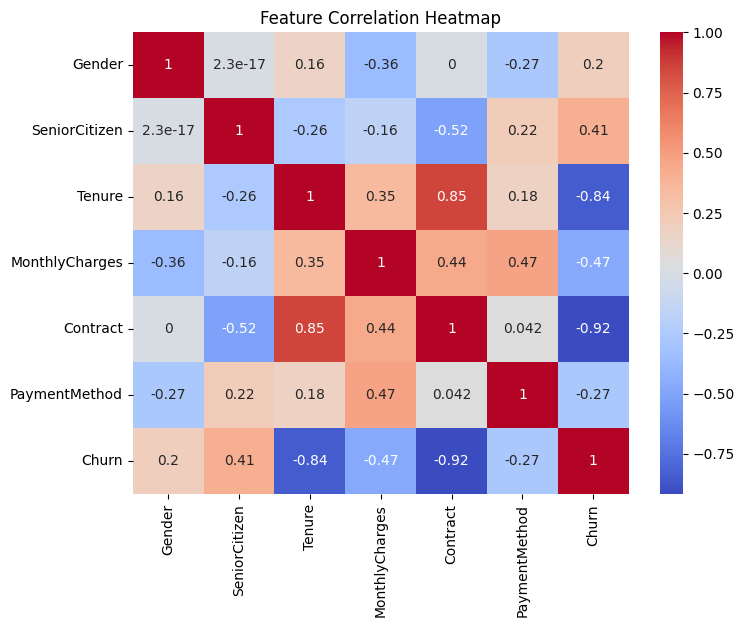


Chi-Square Test
Chi-Square Value : 10.0
p-value : 0.006737946999085469
Significant relationship exists between Contract and Churn

--------------------------------
Logistic Regression
--------------------------------
Accuracy : 0.6666666666666666
Precision : 0.0
Recall : 0.0
F1-Score : 0.0
ROC-AUC : nan

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3



C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_cla

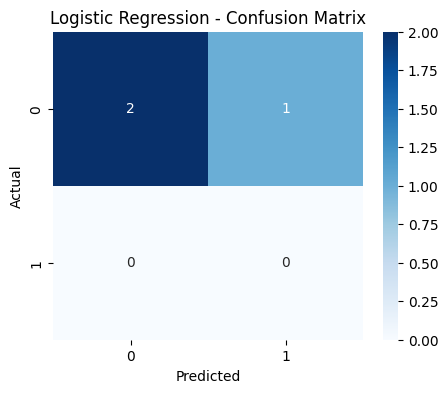

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


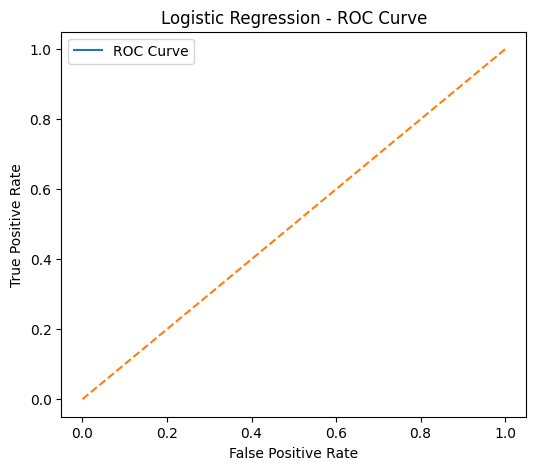


--------------------------------
K-Nearest Neighbors
--------------------------------
Accuracy : 0.3333333333333333
Precision : 0.0
Recall : 0.0
F1-Score : 0.0
ROC-AUC : nan

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.00      0.00      0.00         0

    accuracy                           0.33         3
   macro avg       0.50      0.17      0.25         3
weighted avg       1.00      0.33      0.50         3



C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_cla

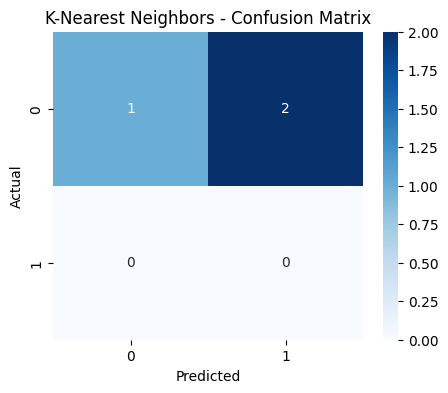

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


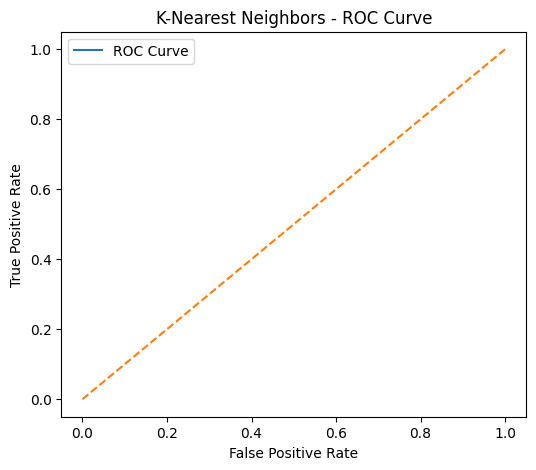


Feature Importance (Logistic Regression)
          Feature  Coefficient
0          Gender     0.066950
1   SeniorCitizen     0.405235
2          Tenure    -0.609501
3  MonthlyCharges    -0.231550
4        Contract    -0.958956
5   PaymentMethod     0.089678


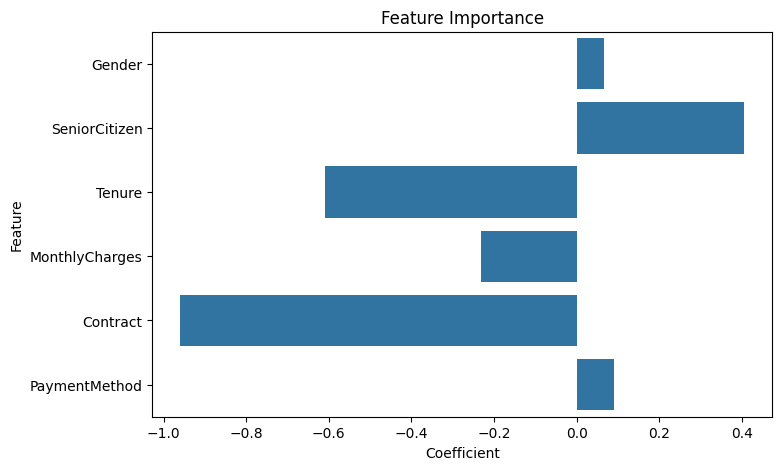


New Customer Prediction
Customer is likely to CHURN


C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# Customer Churn Prediction & Risk Analysis Engine
# -------------------------------------------------
# Required Libraries:
# pip install pandas numpy matplotlib seaborn scikit-learn scipy

# -------------------------------------------------
# Import Libraries
# -------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# -------------------------------------------------
# STEP 1 : Load Dataset
# -------------------------------------------------

# Sample telecom customer dataset

data = {
    'Gender': ['Male','Female','Female','Male','Male','Female','Male','Female','Male','Female'],
    'SeniorCitizen': [0,1,0,0,1,0,1,0,0,1],
    'Tenure': [1,34,2,45,5,22,10,18,50,7],
    'MonthlyCharges': [29.85,56.95,53.85,42.30,70.70,89.10,29.75,80.65,99.65,75.25],
    'Contract': ['Month-to-month','One year','Month-to-month','Two year',
                 'Month-to-month','One year','Month-to-month','Two year',
                 'Two year','Month-to-month'],
    'PaymentMethod': ['Electronic check','Mailed check','Bank transfer',
                      'Credit card','Electronic check','Mailed check',
                      'Bank transfer','Credit card','Electronic check',
                      'Mailed check'],
    'Churn': ['Yes','No','Yes','No','Yes','No','Yes','No','No','Yes']
}

df = pd.DataFrame(data)

print("\nDataset:")
print(df)

# -------------------------------------------------
# STEP 2 : Data Preprocessing
# -------------------------------------------------

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Encode categorical columns
label_encoder = LabelEncoder()

categorical_columns = ['Gender', 'Contract', 'PaymentMethod', 'Churn']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoded Dataset:")
print(df)

# -------------------------------------------------
# STEP 3 : Exploratory Data Analysis
# -------------------------------------------------

# Churn Distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# -------------------------------------------------
# STEP 4 : Statistical Hypothesis Testing
# -------------------------------------------------

print("\nChi-Square Test")

contingency_table = pd.crosstab(df['Contract'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Value :", chi2)
print("p-value :", p)

if p < 0.05:
    print("Significant relationship exists between Contract and Churn")
else:
    print("No significant relationship exists")

# -------------------------------------------------
# STEP 5 : Feature Selection
# -------------------------------------------------

X = df.drop('Churn', axis=1)
y = df['Churn']

# -------------------------------------------------
# STEP 6 : Feature Scaling
# -------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -------------------------------------------------
# STEP 7 : Train-Test Split
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

# -------------------------------------------------
# STEP 8 : Logistic Regression Model
# -------------------------------------------------

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

# Probability prediction for ROC-AUC
log_prob = log_model.predict_proba(X_test)[:,1]

# -------------------------------------------------
# STEP 9 : KNN Model
# -------------------------------------------------

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

knn_prob = knn_model.predict_proba(X_test)[:,1]

# -------------------------------------------------
# STEP 10 : Evaluation Function
# -------------------------------------------------

def evaluate_model(y_test, predictions, probabilities, model_name):

    print("\n--------------------------------")
    print(model_name)
    print("--------------------------------")

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    print("Accuracy :", accuracy)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1-Score :", f1)
    print("ROC-AUC :", roc_auc)

    print("\nClassification Report")
    print(classification_report(y_test, predictions))

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, probabilities)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label='ROC Curve')

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"{model_name} - ROC Curve")

    plt.legend()

    plt.show()

# -------------------------------------------------
# STEP 11 : Evaluate Logistic Regression
# -------------------------------------------------

evaluate_model(
    y_test,
    log_predictions,
    log_prob,
    "Logistic Regression"
)

# -------------------------------------------------
# STEP 12 : Evaluate KNN
# -------------------------------------------------

evaluate_model(
    y_test,
    knn_predictions,
    knn_prob,
    "K-Nearest Neighbors"
)

# -------------------------------------------------
# STEP 13 : Feature Importance
# -------------------------------------------------

print("\nFeature Importance (Logistic Regression)")

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

print(importance)

# Plot Feature Importance
plt.figure(figsize=(8,5))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

# -------------------------------------------------
# STEP 14 : Predict New Customer Churn
# -------------------------------------------------

new_customer = [[1, 0, 12, 85.5, 0, 2]]

new_customer_scaled = scaler.transform(new_customer)

prediction = log_model.predict(new_customer_scaled)

print("\nNew Customer Prediction")

if prediction[0] == 1:
    print("Customer is likely to CHURN")
else:
    print("Customer is NOT likely to churn")

# -------------------------------------------------
# END OF PROJECT
# -------------------------------------------------